AQ1
Pivot + melt + grouped bar
pivot_table(turns by victory_status × winner) → melt() → sns.barplot(hue='winner'). Annotate the median for each group.

In [1]:
import pandas as pd
chess_path="../data/raw/chess_games.csv"
chess_df=pd.read_csv(chess_path)
chess_df.head()


,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,5,Slav Defense: Exchange Variation,Slav Defense,NaN,Exchange Variation
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,NaN,Kennedy Variation
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,NaN,Leonardis Variation
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,NaN,Zukertort Variation
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,5,Philidor Defense,Philidor Defense,NaN,NaN


In [ ]:
#Q1
import seaborn as sns
import matplotlib.pyplot as plt
pivot_table=pd.pivot_table(chess_df,
index='victory_status',
columns='winner',
values='turns',
aggfunc='count',
fill_value=0
)

print(pivot_table)
# Reset index so that 'victory_status' becomes a column
pivot_table_reset = pivot_table.reset_index()

# Melt the dataframe: columns 'victory_status', 'winner', 'count'
melted = pivot_table_reset.melt(id_vars='victory_status', var_name='winner', value_name='count')
print(melted)
# Plot grouped barplot
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=melted, 
    x='victory_status', 
    y='count', 
    hue='winner'
)

# Annotate the median (from the melted counts) for each group (victory_status, winner)
for (status, winner), group in melted.groupby(['victory_status','winner']):
    med = group['count'].median()
    xpos = list(melted['victory_status'].unique()).index(status)
    # Find bar matching this group
    for bar in ax.containers[list(melted['winner'].unique()).index(winner)]:
        # position matches category
        if bar.get_x() <= xpos < bar.get_x() + bar.get_width():
            ax.annotate(f"{int(med)}", (bar.get_x() + bar.get_width()/2, med), 
                        ha='center', va='bottom', fontsize=9, color='black')
            break

plt.title('Number of Turns by Victory Status and Winner')
plt.ylabel('Count of Games')
plt.xlabel('Victory Status')
plt.tight_layout()
plt.show()


winner          Black  Draw  White
victory_status                    
Draw                0   906      0
Mate             2981     0   3344
Out of Time       823    44    813
Resign           5303     0   5844
   victory_status winner  count
0            Draw  Black      0
1            Mate  Black   2981
2     Out of Time  Black    823
3          Resign  Black   5303
4            Draw   Draw    906
5            Mate   Draw      0
6     Out of Time   Draw     44
7          Resign   Draw      0
8            Draw  White      0
9            Mate  White   3344
10    Out of Time  White    813
11         Resign  White   5844


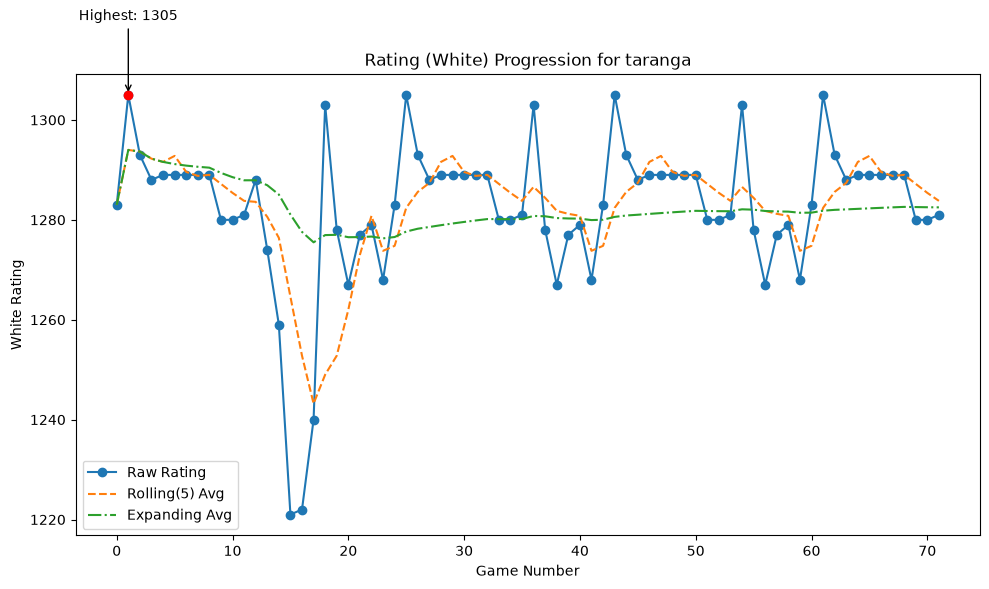

In [ ]:
#Q2
# Rolling analysis — one player
# Choose any player with 15+ games. Plot raw rating + rolling(5) + expanding avg. Annotate their highest-rated game.
# Select a player with 15+ games
player_counts = chess_df['white_id'].value_counts()
selected_player = player_counts[player_counts >= 15].index[0]  
# Filter games for this player as 'white'
player_games = chess_df[chess_df['white_id'] == selected_player].copy()
# Sort by game_id or other time-based column if available (for this demo, use game_id)
player_games = player_games.sort_values('game_id')
# Extract ratings
ratings = player_games['white_rating'].reset_index(drop=True)
# Calculate Rolling(5) avg and Expanding avg
rolling_5 = ratings.rolling(window=5, min_periods=1).mean()
expanding_avg = ratings.expanding().mean()

plt.figure(figsize=(10,6))
plt.plot(ratings, label='Raw Rating', marker='o')
plt.plot(rolling_5, label='Rolling(5) Avg', linestyle='--')
plt.plot(expanding_avg, label='Expanding Avg', linestyle='-.')

# Annotate the highest-rated game
max_rating_idx = ratings.idxmax()
max_rating = ratings[max_rating_idx]
plt.scatter(max_rating_idx, max_rating, color='red', zorder=5)
plt.annotate(
    f'Highest: {max_rating}', 
    xy=(max_rating_idx, max_rating), 
    xytext=(max_rating_idx, max_rating+15), 
    arrowprops=dict(facecolor='red', arrowstyle='->'),
    ha='center'
)

plt.title(f'Rating (White) Progression for {selected_player}')
plt.xlabel('Game Number')
plt.ylabel('White Rating')
plt.legend()
plt.tight_layout()
plt.show()